## Imports

This section loads the libraries used for data preparation, transfer learning, and evaluation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

## Device

This section checks the available device for training.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


## Dataset paths

This section defines the dataset directories.

In [3]:
data_dir = Path("../data/raw/fer2013")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

print("Train path:", train_dir.resolve())
print("Test path:", test_dir.resolve())

Train path: C:\Users\harsh\facial-emotion-recognition-cv\data\raw\fer2013\train
Test path: C:\Users\harsh\facial-emotion-recognition-cv\data\raw\fer2013\test


## Transforms

This section prepares the image preprocessing steps for MobileNetV2.

In [4]:
image_size = (224, 224)
batch_size = 64

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Image size:", image_size)
print("Batch size:", batch_size)

Image size: (224, 224)
Batch size: 64


## Dataset loading

This section loads the training and test datasets.

In [5]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Training samples: 28709
Test samples: 7178


## Data loaders

This section creates the data loaders used during training and testing.

In [6]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 449
Test batches: 113


## Sample batch

This section checks a batch from the training loader.

In [7]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])


## Model

This section fine-tunes the last feature layers of MobileNetV2 for facial emotion classification.

In [20]:
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# Freeze all layers first
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last few layers for fine-tuning
for param in model.features[-4:].parameters():
    param.requires_grad = True

# Replace classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(class_names))

model = model.to(device)
print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

## Loss and optimizer

This section defines the training objective.

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)
print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: CrossEntropyLoss()
Optimizer: Adam


## Training settings

This section sets the number of training epochs.

In [23]:
epochs = 10

print("Epochs:", epochs)

Epochs: 10


## Training loop

This section trains the classifier layer and records the training history.

In [24]:
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

Epoch 01/10 | Train Loss: 1.4841 | Train Acc: 0.4257
Epoch 02/10 | Train Loss: 1.1759 | Train Acc: 0.5554
Epoch 03/10 | Train Loss: 1.0157 | Train Acc: 0.6219
Epoch 04/10 | Train Loss: 0.8701 | Train Acc: 0.6807
Epoch 05/10 | Train Loss: 0.7180 | Train Acc: 0.7418
Epoch 06/10 | Train Loss: 0.5680 | Train Acc: 0.8014
Epoch 07/10 | Train Loss: 0.4246 | Train Acc: 0.8572
Epoch 08/10 | Train Loss: 0.3007 | Train Acc: 0.9032
Epoch 09/10 | Train Loss: 0.2075 | Train Acc: 0.9376
Epoch 10/10 | Train Loss: 0.1466 | Train Acc: 0.9587


## Training history

This section shows the loss trend during training.

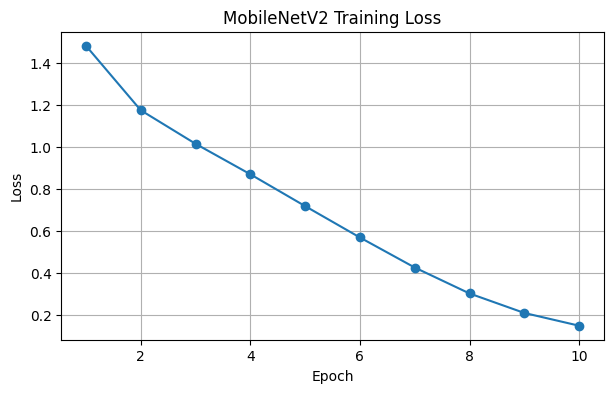

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training Loss")
plt.grid(True)
plt.show()

## Training accuracy

This section shows the accuracy trend during training.

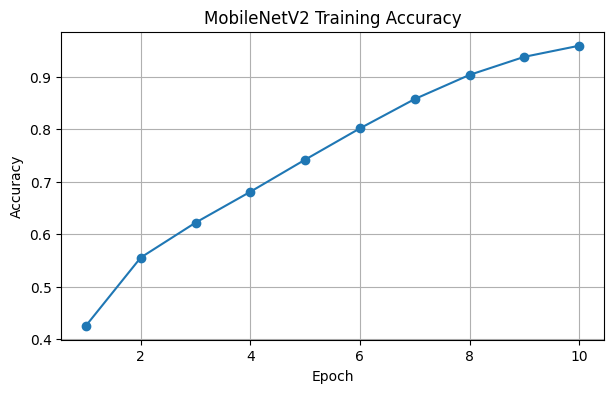

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training Accuracy")
plt.grid(True)
plt.show()

## Test evaluation

This section evaluates the trained model on the test set.

In [27]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.5600


In [28]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Classification Report:

              precision    recall  f1-score   support

       angry     0.4553    0.4676    0.4614       958
     disgust     0.6053    0.4144    0.4920       111
        fear     0.3895    0.4111    0.4000      1024
       happy     0.7788    0.7700    0.7744      1774
     neutral     0.4992    0.5272    0.5128      1233
         sad     0.4499    0.3994    0.4231      1247
    surprise     0.6762    0.7112    0.6933       831

    accuracy                         0.5600      7178
   macro avg     0.5506    0.5287    0.5367      7178
weighted avg     0.5603    0.5600    0.5595      7178



## Confusion matrix

This section shows the class-wise test results.

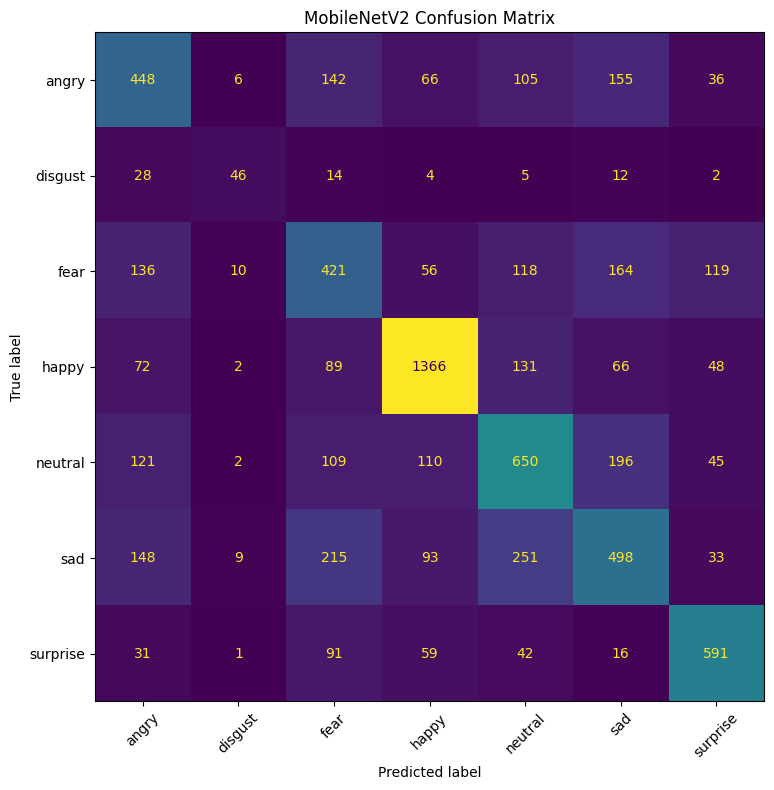

In [29]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.show()

## Sample predictions

This section displays a few predictions from the test set.

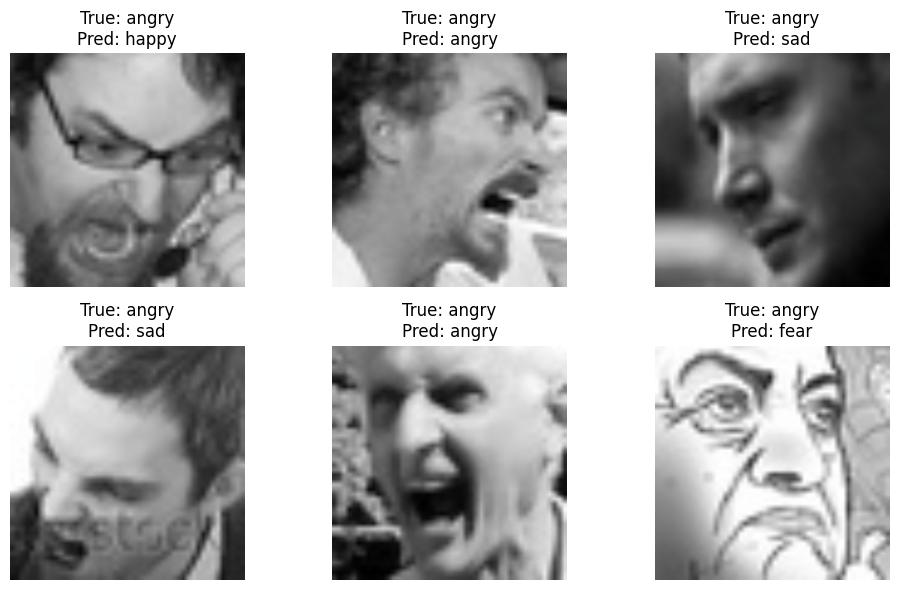

In [30]:
sample_images = []
sample_true = []
sample_pred = []

for i in range(6):
    image, label = test_dataset[i]
    image_input = image.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_input)
        pred = torch.argmax(output, dim=1).item()

    image_np = image.permute(1, 2, 0).numpy()
    image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    image_np = np.clip(image_np, 0, 1)

    sample_images.append(image_np)
    sample_true.append(class_names[label])
    sample_pred.append(class_names[pred])

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"True: {sample_true[i]}\nPred: {sample_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Model save

This section saves the trained model checkpoint.

In [31]:
torch.save(model.state_dict(), "../outputs/checkpoints/mobilenetv2.pth")
print("Model saved to ../outputs/checkpoints/mobilenetv2.pth")

Model saved to ../outputs/checkpoints/mobilenetv2.pth


## Observation

The fine-tuned MobileNetV2 model shows a significant improvement over the frozen version and achieves performance comparable to the custom CNN. The training curves indicate effective learning, with a steady decrease in loss and a strong increase in training accuracy. The confusion matrix shows better class separation, particularly for happy, surprise, and neutral, while performance remains moderate for fear and sad. Compared to the frozen model, predictions are more balanced across classes, indicating that fine-tuning enables the network to adapt to the FER2013 dataset.

## Report note

A fine-tuned MobileNetV2 model is used to improve transfer learning performance by unfreezing the deeper feature layers. This allows the model to adapt pretrained representations to the target dataset. The results show a clear improvement over the frozen model, demonstrating the importance of fine-tuning when there is a domain mismatch. The performance is comparable to the custom CNN, confirming that both learned and transferred features can be effective when properly optimised.

## Final comparison

This section compares the performance of all implemented models for facial emotion classification.

The LBP + SVM model achieves the lowest performance and shows strong bias towards the "happy" class, indicating that simple texture features are insufficient for capturing complex facial expressions. The HOG + SVM model improves performance by capturing gradient-based features, resulting in better class separation but still limited accuracy.

The custom CNN significantly improves performance by learning hierarchical features directly from the data. It achieves the highest accuracy and provides more balanced predictions across classes.

The MobileNetV2 model, when used with frozen feature layers, performs similarly to HOG + SVM due to domain mismatch. However, fine-tuning the deeper layers allows the model to adapt to the dataset, resulting in a substantial performance improvement and accuracy comparable to the custom CNN.

Overall, deep learning models outperform traditional methods, and fine-tuning is essential when applying transfer learning to domain-specific data such as grayscale facial images.

| Model                     | Accuracy | Key Behaviour |
|--------------------------|---------|--------------|
| LBP + SVM                | ~25%    | Strong bias, poor separation |
| HOG + SVM                | ~43%    | Improved but limited |
| Custom CNN               | ~57%    | Best performance |
| MobileNetV2 (frozen)     | ~43%    | Domain mismatch |
| MobileNetV2 (fine-tuned) | ~56%    | Strong improvement |

The results demonstrate that learned representations outperform handcrafted features, and that transfer learning requires fine-tuning to achieve optimal performance on domain-specific datasets.